In [1]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")
# =========================================================
# MLFLOW EXPERIMENT
# =========================================================
mlflow.set_experiment(
    "LinearSVC_30Trials"
)

c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/17 23:37:30 INFO mlflow.tracking.fluent: Experiment with name 'LinearSVC_30Trials' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/Soham/Documents/youtube comment '
 'analyzer/mlruns/735785313799030500'), creation_time=1779041251011, experiment_id='735785313799030500', last_update_time=1779041251011, lifecycle_stage='active', name='LinearSVC_30Trials', tags={}, trace_location=None, workspace='default'>

CLASSES:
[ 1 -1  0]

CLASS COUNTS:

category
 1    15770
 0    12644
-1     8248
Name: count, dtype: int64


[I 2026-05-17 23:38:02,838] A new study created in memory with name: no-name-5da4f168-8a09-4ace-98f8-a5b1e10b6a1b
[I 2026-05-17 23:39:13,699] Trial 0 finished with value: 0.8319730723963991 and parameters: {'C': 1.5012480700165245}. Best is trial 0 with value: 0.8319730723963991.
[I 2026-05-17 23:41:06,184] Trial 1 finished with value: 0.8023187885671539 and parameters: {'C': 0.08609663180922843}. Best is trial 0 with value: 0.8319730723963991.
[I 2026-05-17 23:42:10,402] Trial 2 finished with value: 0.28348592932304123 and parameters: {'C': 0.0004703228773813553}. Best is trial 0 with value: 0.8319730723963991.
[I 2026-05-17 23:43:20,470] Trial 3 finished with value: 0.2011511428429732 and parameters: {'C': 0.00015176939253710997}. Best is trial 0 with value: 0.8319730723963991.
[I 2026-05-17 23:45:08,966] Trial 4 finished with value: 0.21085703107913398 and parameters: {'C': 0.00023723673934591543}. Best is trial 0 with value: 0.8319730723963991.
[I 2026-05-17 23:47:00,121] Trial 5 f

BEST PARAMETERS
{'C': 0.6791556430557995}

Accuracy    : 0.8559
Macro F1    : 0.8418
Weighted F1 : 0.8543

Classification Report:

              precision    recall  f1-score   support

          -1       0.80      0.73      0.76      1650
           0       0.83      0.95      0.89      2529
           1       0.91      0.85      0.87      3154

    accuracy                           0.86      7333
   macro avg       0.85      0.84      0.84      7333
weighted avg       0.86      0.86      0.85      7333



2026/05/18 00:31:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RESULTS DATAFRAME:

     Best_C  Accuracy  Macro_F1  Weighted_F1
0  0.679156  0.855857  0.841844      0.85434


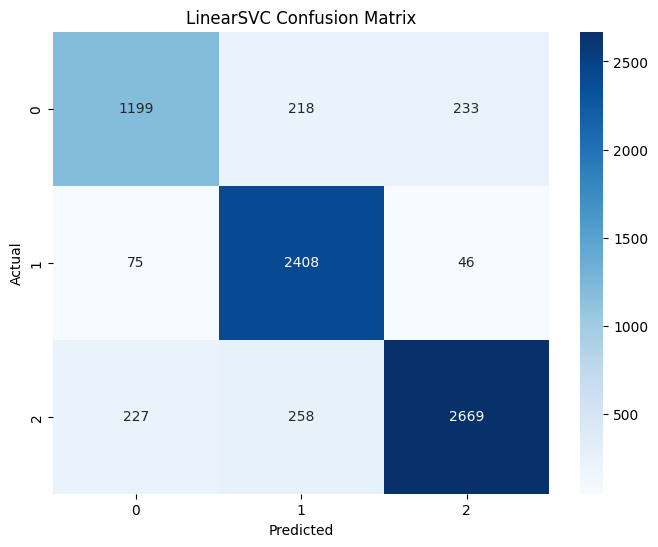

In [2]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import optuna
import mlflow

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(42)

# =========================================================
# LOAD DATASET
# =========================================================
df_original = pd.read_csv(
    "reddit_preprocessing.csv"
).dropna()

# =========================================================
# SAFE COPY
# =========================================================
df = df_original.copy()

# =========================================================
# VERIFY CLASSES
# =========================================================
print("=" * 60)

print("CLASSES:")

print(df['category'].unique())

print("\nCLASS COUNTS:\n")

print(df['category'].value_counts())

print("=" * 60)

# =========================================================
# FEATURES / TARGET
# =========================================================
X_text = df['clean_comment']

y = df['category']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train_text, X_test_text, y_train, y_test = train_test_split(

    X_text,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# =========================================================
# TF-IDF SETTINGS
# =========================================================
ngram_range = (1, 3)

max_features = 5000

# =========================================================
# CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=42
)



# =========================================================
# RESULTS STORAGE
# =========================================================
results = []

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================
def objective_linearsvc(trial):

    params = {

        "C": trial.suggest_float(
            "C",
            1e-4,
            5.0,
            log=True
        ),

        "class_weight": "balanced",

        "random_state": 42,

        "max_iter": 5000
    }

    # =====================================================
    # PIPELINE
    # =====================================================
    pipeline = Pipeline([

        (
            "tfidf",

            TfidfVectorizer(

                ngram_range=ngram_range,

                max_features=max_features,

                min_df=3,

                max_df=0.90,

                sublinear_tf=True
            )
        ),

        (
            "model",

            LinearSVC(
                **params
            )
        )
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================
    scores = cross_val_score(

        pipeline,

        X_train_text,

        y_train,

        cv=cv,

        scoring='f1_macro',

        n_jobs=1
    )

    return np.mean(scores)

# =========================================================
# RUN OPTUNA
# =========================================================
study = optuna.create_study(
    direction="maximize"
)

study.optimize(

    objective_linearsvc,

    n_trials=30
)

# =========================================================
# BEST PARAMETERS
# =========================================================
print("=" * 60)

print("BEST PARAMETERS")

print(study.best_params)

print("=" * 60)

# =========================================================
# FINAL PIPELINE
# =========================================================
best_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            ngram_range=ngram_range,

            max_features=max_features,

            min_df=3,

            max_df=0.90,

            sublinear_tf=True
        )
    ),

    (
        "model",

        LinearSVC(

            C=study.best_params['C'],

            class_weight='balanced',

            random_state=42,

            max_iter=5000
        )
    )
])

# =========================================================
# TRAIN FINAL MODEL
# =========================================================
best_pipeline.fit(

    X_train_text,

    y_train
)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = best_pipeline.predict(
    X_test_text
)

# =========================================================
# METRICS
# =========================================================
accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(

    y_test,

    y_pred,

    average='macro'
)

weighted_f1 = f1_score(

    y_test,

    y_pred,

    average='weighted'
)

# =========================================================
# STORE RESULTS
# =========================================================
results.append({

    "Best_C": study.best_params['C'],

    "Accuracy": accuracy,

    "Macro_F1": macro_f1,

    "Weighted_F1": weighted_f1
})

# =========================================================
# RESULTS
# =========================================================
print(f"\nAccuracy    : {accuracy:.4f}")

print(f"Macro F1    : {macro_f1:.4f}")

print(f"Weighted F1 : {weighted_f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(

    conf_matrix,

    annot=True,

    fmt='d',

    cmap='Blues',

    ax=ax
)

ax.set_xlabel("Predicted")

ax.set_ylabel("Actual")

ax.set_title(
    "LinearSVC Confusion Matrix"
)

# =========================================================
# MLFLOW LOGGING
# =========================================================
with mlflow.start_run(
    run_name="LinearSVC_30Trials"
):

    mlflow.set_tag(
        "model",
        "LinearSVC"
    )

    mlflow.set_tag(
        "vectorizer",
        "TF-IDF"
    )

    mlflow.log_param(
        "ngram_range",
        ngram_range
    )

    mlflow.log_param(
        "max_features",
        max_features
    )

    mlflow.log_params(
        study.best_params
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "macro_f1",
        macro_f1
    )

    mlflow.log_metric(
        "weighted_f1",
        weighted_f1
    )

    # -----------------------------------------------------
    # CLASSIFICATION REPORT
    # -----------------------------------------------------
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    for label, metrics in report.items():

        if isinstance(metrics, dict):

            for metric_name, metric_value in metrics.items():

                mlflow.log_metric(
                    f"{label}_{metric_name}",
                    metric_value
                )

    # -----------------------------------------------------
    # CONFUSION MATRIX
    # -----------------------------------------------------
    mlflow.log_figure(
        fig,
        "linearsvc_confusion_matrix.png"
    )

    # -----------------------------------------------------
    # SAVE MODEL
    # -----------------------------------------------------
    mlflow.sklearn.log_model(

        sk_model=best_pipeline,

        name="linearsvc_pipeline"
    )

# =========================================================
# RESULTS DATAFRAME
# =========================================================
results_df = pd.DataFrame(results)

print("\nRESULTS DATAFRAME:\n")

print(results_df)

plt.show()

plt.close(fig)